## Task 2

In [56]:
'''1. Read the dataset and seperate the input and output columns 2. Plot
the graph of class balancing
3. Perform train-test split with 75% and 25%
4. Create decision tree model
5. Find accuracy, confusion matrix and classification report 6.
Perform the prediction of single value entry.
7. Plot and save the tree.
''';

In [57]:
import zipfile


with zipfile.ZipFile("balance+scale.zip", 'r') as zip_ref:
    zip_ref.extractall()


In [58]:
import pandas as pd

df = pd.read_csv("balance-scale.data", header=None)


In [59]:
df.columns = ['Class', 'Left-Weight', 'Left-Distance', 'Right-Weight', 'Right-Distance']


In [60]:
df

,Class,Left-Weight,Left-Distance,Right-Weight,Right-Distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5
...,...,...,...,...,...
620,L,5,5,5,1
621,L,5,5,5,2
622,L,5,5,5,3
623,L,5,5,5,4


In [61]:
df.head()

,Class,Left-Weight,Left-Distance,Right-Weight,Right-Distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


In [62]:
df.shape

(625, 5)

In [63]:

X = df.drop('Class', axis=1) 
y = df['Class']              

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (625, 4)
y shape: (625,)


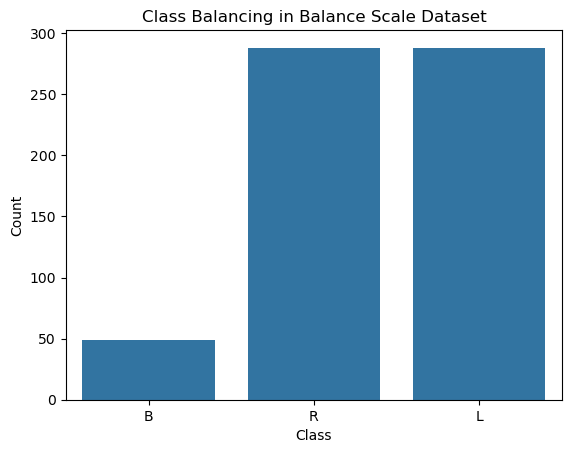

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.countplot(x='Class', data=df)
plt.title('Class Balancing in Balance Scale Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (468, 4)
X_test shape: (157, 4)
y_train shape: (468,)
y_test shape: (157,)


In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7707006369426752

Confusion Matrix:
[[ 1  9  4]
 [ 7 58  1]
 [ 9  6 62]]

Classification Report:
              precision    recall  f1-score   support

           B       0.06      0.07      0.06        14
           L       0.79      0.88      0.83        66
           R       0.93      0.81      0.86        77

    accuracy                           0.77       157
   macro avg       0.59      0.59      0.59       157
weighted avg       0.79      0.77      0.78       157



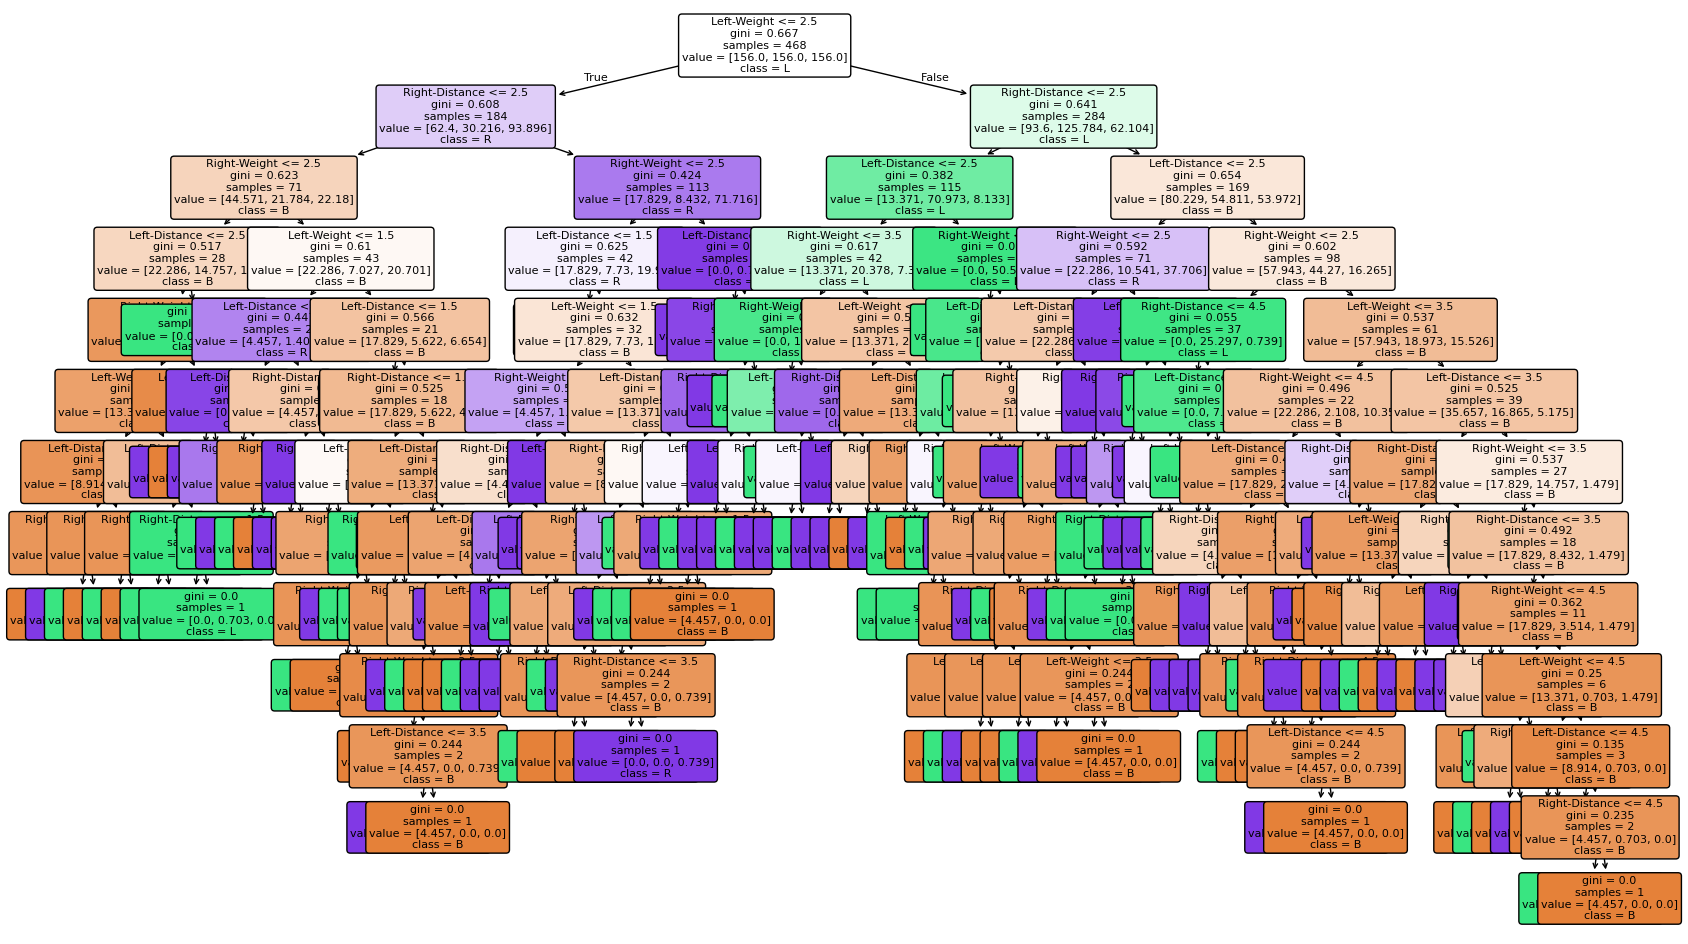

In [67]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,12)) 
plot_tree(model, 
          feature_names=['Left-Weight','Left-Distance','Right-Weight','Right-Distance'], 
          class_names=['B','L','R'], 
          filled=True,  
          rounded=True,
          fontsize=8)


plt.show()

In [68]:
new_entry = [[1, 4, 7, 5]]

prediction = model.predict(new_entry)


class_names = {'B': 'Balance', 'L': 'Left', 'R': 'Right'}
result = class_names[prediction[0]]

print("New :", new_entry)
print("Prediction:", result)

New : [[1, 4, 7, 5]]
Prediction: Right


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [69]:
import joblib 


joblib.dump(model, 'balance_model.pkl')

print("Model saved as balance_model.pkl")

Model saved as balance_model.pkl
